<a href="https://colab.research.google.com/github/lakshmiakkina/lakshmiakkina/blob/main/salesofchocolatestores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load your dataset. Replace 'your_dataset.csv' with the actual path to your file.
df = pd.read_csv('D:\sales_dataset') # <--- Please replace 'your_dataset.csv' with your file path

# Display the first 5 rows to get a quick overview of the data
display(df.head())

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13546/3115353746.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('D:\sales_dataset') # <--- Please replace 'your_dataset.csv' with your file path


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\sales_dataset'

In [ ]:
import pandas as pd

# Load stores dataset
stores_df = pd.read_csv('/content/stores.csv')
print('Stores DataFrame Head:')
display(stores_df.head())

# Load sales dataset
sales_df = pd.read_csv('/content/sales.csv')
print('\nSales DataFrame Head:')
display(sales_df.head())

# Load products dataset
products_df = pd.read_csv('/content/products.csv')
print('\nProducts DataFrame Head:')
display(products_df.head())

# Load customers dataset
customers_df = pd.read_csv('/content/customers.csv')
print('\nCustomers DataFrame Head:')
display(customers_df.head())

# Load calendar dataset
calendar_df = pd.read_csv('/content/calendar.csv')
print('\nCalendar DataFrame Head:')
display(calendar_df.head())

Stores DataFrame Head:


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online



Sales DataFrame Head:


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40



Products DataFrame Head:


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50



Customers DataFrame Head:


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31



Calendar DataFrame Head:


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [ ]:
print('Null values in stores_df:')
display(stores_df.isnull().sum())

print('\nNull values in sales_df:')
display(sales_df.isnull().sum())

print('\nNull values in products_df:')
display(products_df.isnull().sum())

print('\nNull values in customers_df:')
display(customers_df.isnull().sum())

print('\nNull values in calendar_df:')
display(calendar_df.isnull().sum())

Null values in stores_df:


,0
store_id,0
store_name,0
city,0
country,0
store_type,0



Null values in sales_df:


,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0



Null values in products_df:


,0
product_id,0
product_name,0
brand,0
category,0
cocoa_percent,0
weight_g,0



Null values in customers_df:


,0
customer_id,0
age,0
gender,0
loyalty_member,0
join_date,0



Null values in calendar_df:


,0
date,0
year,0
month,0
day,0
week,0
day_of_week,0


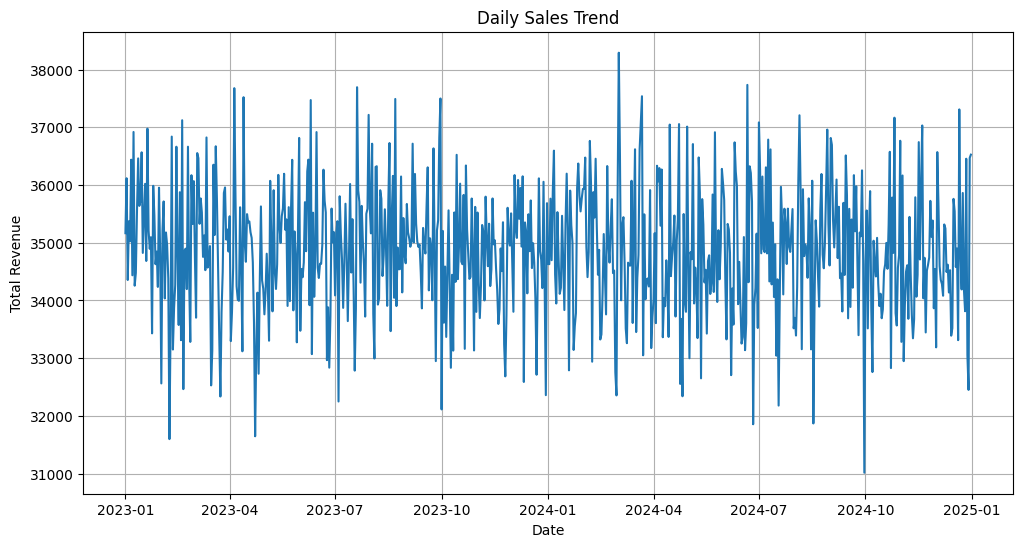

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'order_date' to datetime in sales_df
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])

# Convert 'date' to datetime in calendar_df
calendar_df['date'] = pd.to_datetime(calendar_df['date'])

# Merge sales_df with calendar_df on date columns
sales_calendar_df = pd.merge(sales_df, calendar_df, left_on='order_date', right_on='date', how='left')

# Calculate daily sales
daily_sales = sales_calendar_df.groupby('order_date')['revenue'].sum().reset_index()

# Plot daily sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='order_date', y='revenue', data=daily_sales)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

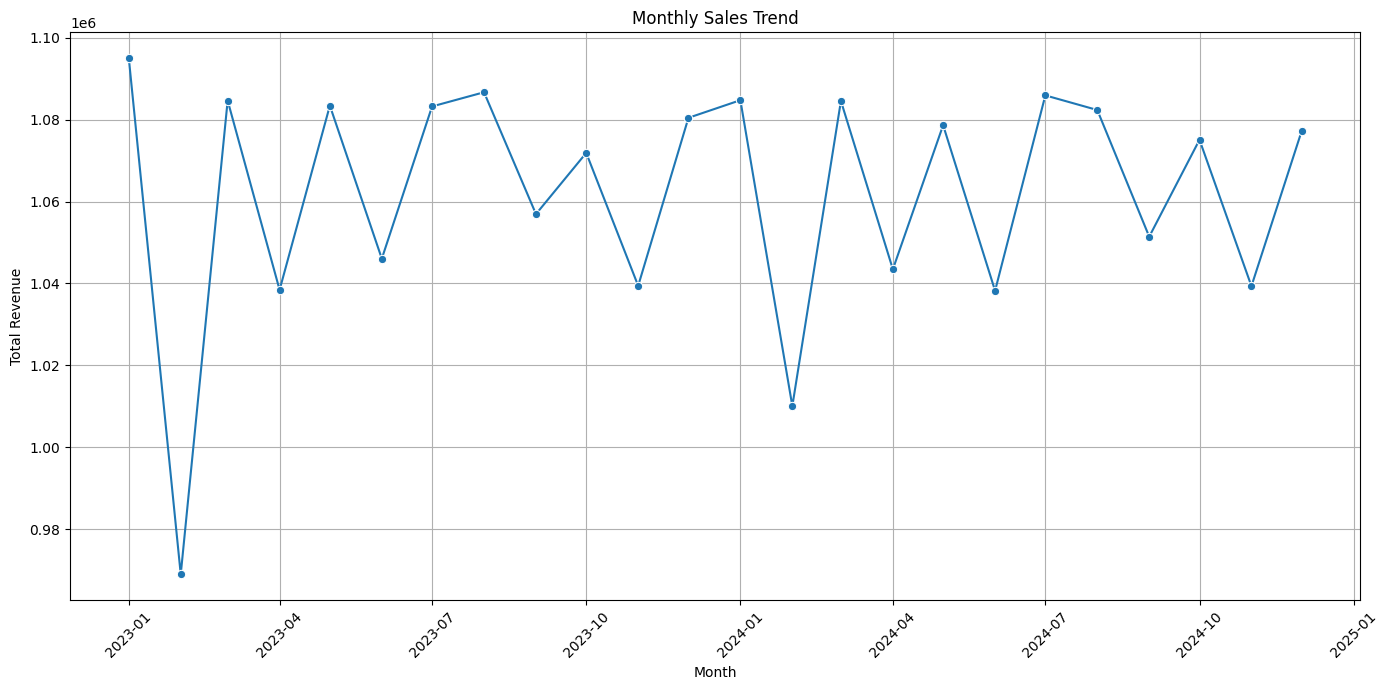

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract month from 'order_date' and create a 'month_year' column for better grouping
sales_calendar_df['month_year'] = sales_calendar_df['order_date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = sales_calendar_df.groupby('month_year')['revenue'].sum().reset_index()

# Convert 'month_year' back to datetime for plotting
monthly_sales['month_year'] = monthly_sales['month_year'].dt.to_timestamp()

# Plot monthly sales trend
plt.figure(figsize=(14, 7))
sns.lineplot(x='month_year', y='revenue', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

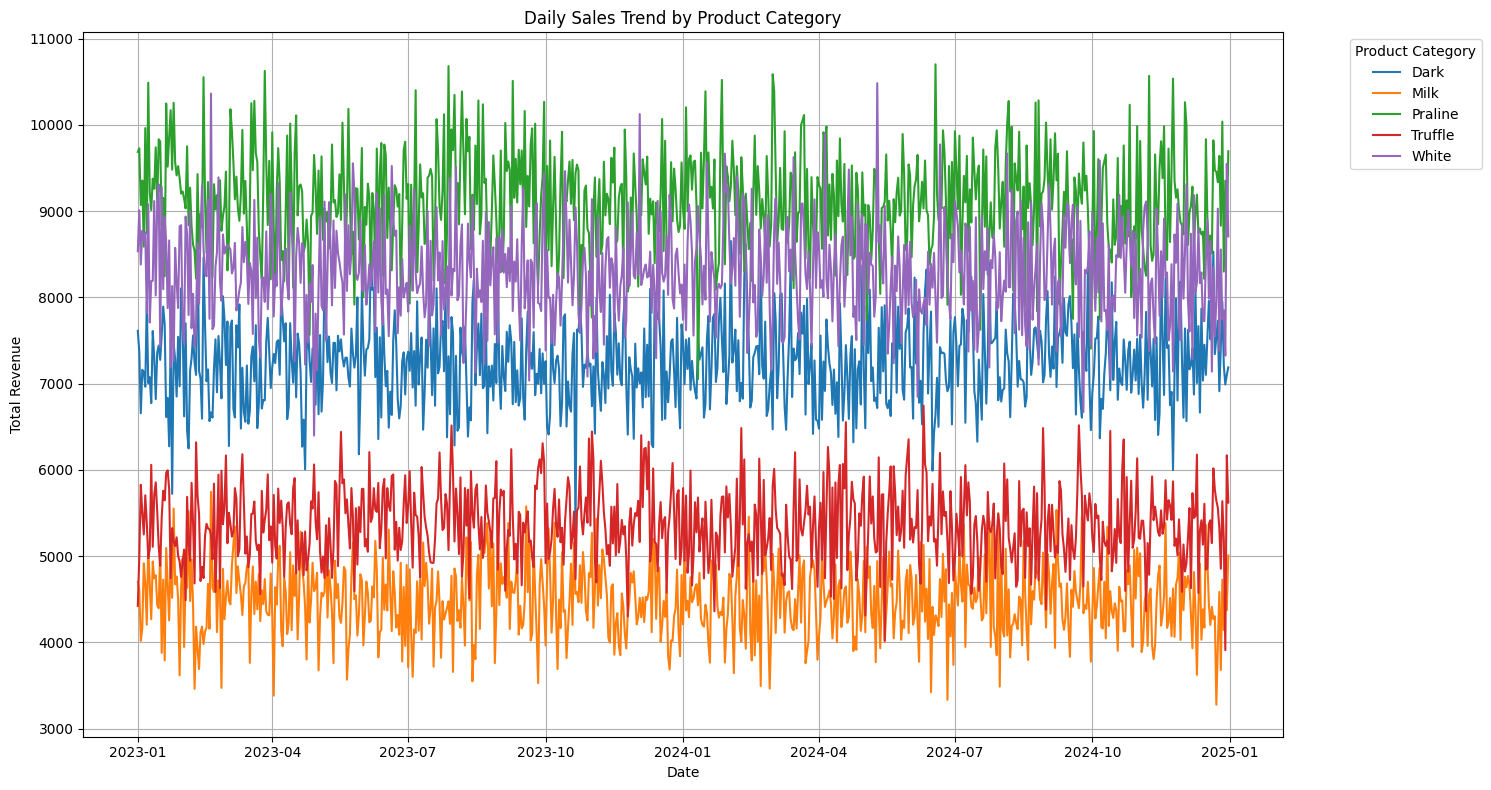

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge sales_calendar_df with products_df to get product categories
sales_product_df = pd.merge(sales_calendar_df, products_df, on='product_id', how='left')

# Calculate daily sales by product category
daily_category_sales = sales_product_df.groupby(['order_date', 'category'])['revenue'].sum().reset_index()

# Plot daily sales trend for each product category
plt.figure(figsize=(15, 8))
sns.lineplot(x='order_date', y='revenue', hue='category', data=daily_category_sales)
plt.title('Daily Sales Trend by Product Category')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Total Sales per Store (Top 10):


,store_name,revenue
72,Chocolate Store 74,261393.77
27,Chocolate Store 33,260672.37
46,Chocolate Store 50,259526.62
84,Chocolate Store 85,259512.15
98,Chocolate Store 98,259055.13
20,Chocolate Store 27,259006.23
15,Chocolate Store 22,258914.68
24,Chocolate Store 30,258231.17
5,Chocolate Store 13,258185.98
90,Chocolate Store 90,258135.85


/tmp/ipykernel_13546/516007631.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='store_name', y='revenue', data=total_sales_per_store.head(10), palette='viridis')


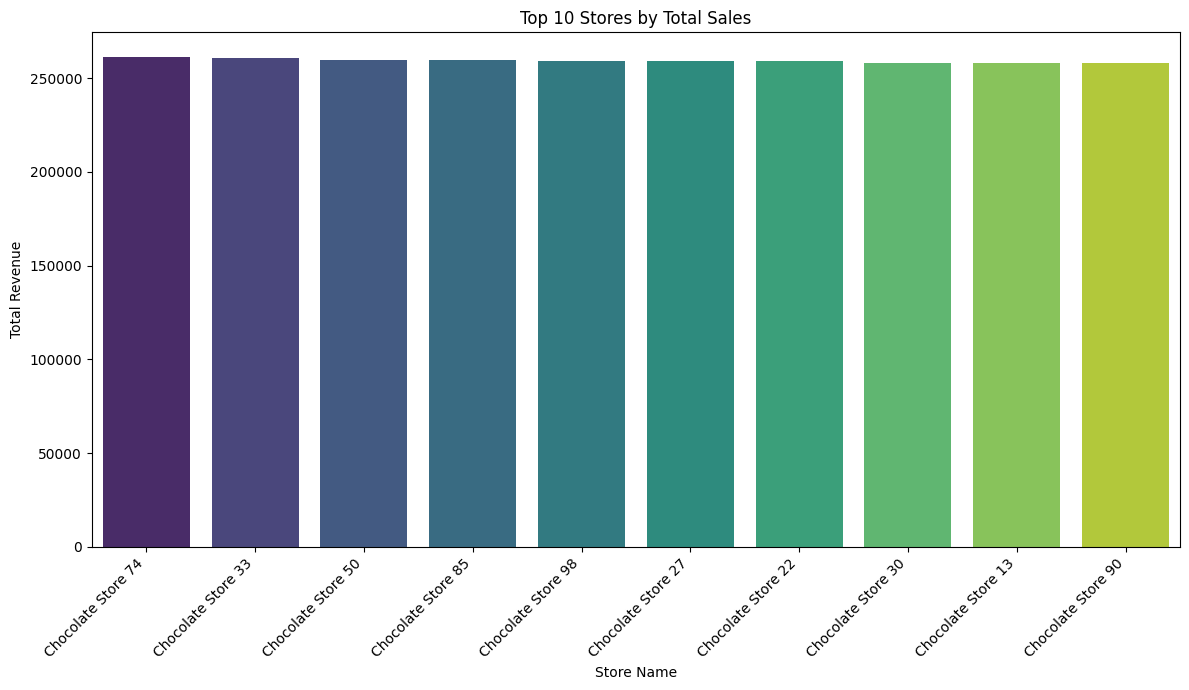

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge sales_calendar_df with stores_df to get store names
sales_stores_df = pd.merge(sales_calendar_df, stores_df, on='store_id', how='left')

# Calculate total sales per store
total_sales_per_store = sales_stores_df.groupby('store_name')['revenue'].sum().reset_index()

# Sort in descending order and display the top 10 stores
total_sales_per_store = total_sales_per_store.sort_values(by='revenue', ascending=False)
print('Total Sales per Store (Top 10):')
display(total_sales_per_store.head(10))

# Plotting total sales per store for the top 10
plt.figure(figsize=(12, 7))
sns.barplot(x='store_name', y='revenue', data=total_sales_per_store.head(10), palette='viridis')
plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Display total sales for all stores
print('Total Sales per Store (All Stores):')
display(total_sales_per_store)

Total Sales per Store (All Stores):


,store_name,revenue
72,Chocolate Store 74,261393.77
27,Chocolate Store 33,260672.37
46,Chocolate Store 50,259526.62
84,Chocolate Store 85,259512.15
98,Chocolate Store 98,259055.13
...,...,...
75,Chocolate Store 77,250220.40
12,Chocolate Store 2,249737.67
43,Chocolate Store 48,249272.38
53,Chocolate Store 57,248778.57


Please examine the output above and identify the column that represents time (e.g., 'Date', 'Timestamp', 'Year'). Once you've identified it, I can help you plot trends over time.